In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Cvičení: Lineární a polynomiální regrese

### Úkol 1: Načtěte dataset ze souboru Synthetic dataset.csv. Identifikujte vstupní proměnnou X a cílovou proměnnou Y (podle názvů sloupců v CSV).

In [3]:
file_path = "Datasets/Synthetic_dataset.csv"
df = pd.read_csv(file_path)
print(df.head())

# Select features
X = df["X"].values.reshape(-1, 1)
y = df["Y"].values
# print(X)
# print(y)

          X          Y
0 -3.000000  33.652460
1 -2.979933  32.110669
2 -2.959866  32.589028
3 -2.939799  33.204325
4 -2.919732  30.107067


Úkol 2: Vytvořte bodový graf (scatterplot) Y = f(X). Osa x: vstupní proměnná, osa y: cílová proměnná. Uložte graf do formátu png. Vytvořte bodový graf (scatterplot) Y = f (X ). Osa x : vstupní proměnná, osa y : cílová proměnná. Uložte graf do formátu png.

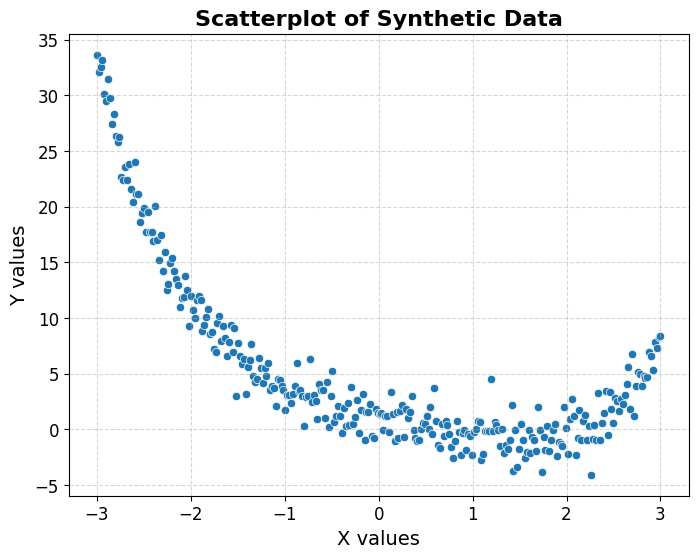

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

### 3. Natrénujte následující regresní modely:
- lineární regresi,
- polynomiální regresi pro stupně d ∈ {2, 3, 4, 5, 6, 7}.

Pro každý model vytvořte predikce ŷ na stejných datech (nebo na testovací množině, pokud provedete rozdělení).

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_reg = lin_reg.predict(X_test)


mse_lin = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin_reg)
r2_lin = r2_score(y_test, y_pred_lin_reg)

# rows: different models, columns: different metrics
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MSE": [mse_lin],
    "RMSE": [rmse_lin],
    "MAE": [mae_lin],
    "R2 Score": [r2_lin]
})
# print(results)


degrees = [2, 3, 4, 5, 6, 7]
y_poly_pred = {}
poly_regs = {}


for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly_train, y_train)
    poly_regs[degree] = poly_reg

    y_poly_pred[degree] = poly_reg.predict(X_poly_test)
    mse_poly = mean_squared_error(y_test, y_poly_pred[degree])
    rmse_poly = np.sqrt(mse_poly)
    mae_poly = mean_absolute_error(y_test, y_poly_pred[degree])
    r2_poly = r2_score(y_test, y_poly_pred[degree])
    
    new_row = pd.DataFrame({
        "Model": [f"Polynomial Regression (degree={degree})"],
        "MSE": [mse_poly],
        "RMSE": [rmse_poly],
        "MAE": [mae_poly],
        "R2 Score": [r2_poly]
    })
    results = pd.concat([results, new_row], ignore_index=True)


4. Vypočıtejte pro každý model následující metriky kvality:
    - MSE, RMSE, MAE, R^2
Výsledky uložte do tabulky (např. pandas DataFrame) a určete nejlepší polynomiální stupenň na základě metrik.

In [6]:
print(results.sort_values(by="MSE", ascending=True))

                              Model        MSE      RMSE       MAE  R2 Score
3  Polynomial Regression (degree=4)   1.320681  1.149209  0.880793  0.978301
4  Polynomial Regression (degree=5)   1.361519  1.166841  0.886694  0.977630
5  Polynomial Regression (degree=6)   1.390499  1.179194  0.910980  0.977154
6  Polynomial Regression (degree=7)   1.409376  1.187171  0.913219  0.976843
2  Polynomial Regression (degree=3)   3.203969  1.789963  1.488703  0.947358
1  Polynomial Regression (degree=2)   4.372322  2.091010  1.685629  0.928161
0                 Linear Regression  28.991143  5.384342  4.112627  0.523665


## Nejlepší polynomiální stupeň na základě metrik je 4.

### 5. Vytvořte jeden společný graf (1 okno), ve kterém zobrazíte:
- scatterplot dat,
- regresní přímku lineární regrese,
- regresní křivky polynomiálních regresí pro d = 2, . . . , 7.

Každou regresní křivku vykreslete jinou barvou a přidejte legendu. Uložte graf do formátu png.

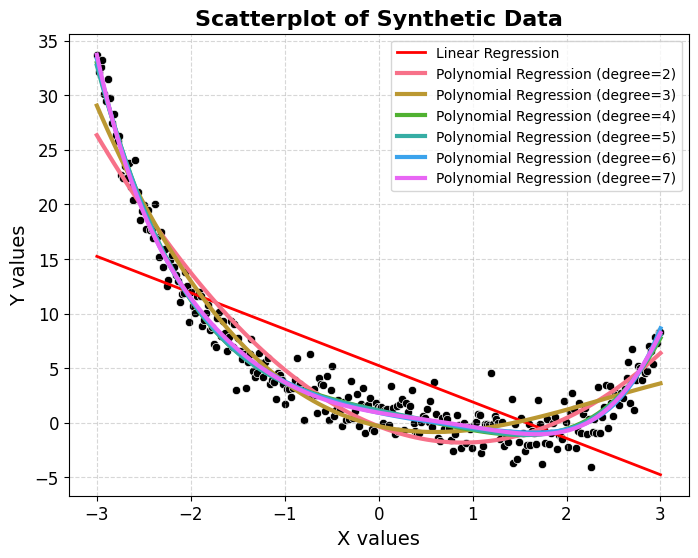

In [10]:
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y", color='black')
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency

# Plot linear regression (using X_test is not ideal for a line plot as points are unordered, better to use grid)
lin_reg_pred_grid = lin_reg.predict(X_grid)
plt.plot(X_grid, lin_reg_pred_grid, color="red", linewidth=2, label="Linear Regression")

colors = sns.color_palette("husl", len(degrees))
for i, degree in enumerate(degrees):
    # Create polynomial features for the specific degree
    poly_temp = PolynomialFeatures(degree=degree)
    X_poly_grid = poly_temp.fit_transform(X_grid)
    
    # Predict
    y_poly_grid = poly_regs[degree].predict(X_poly_grid)
    plt.plot(X_grid, y_poly_grid, color=colors[i], linewidth=3, label=f"Polynomial Regression (degree={degree})")

plt.legend()
plt.savefig("polynomial_regression_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### 6. Pro polynomiální regresi vytvořte závislosti metrik na stupni polynomu d ∈{2, . . . , 7}.
### 7. Vytvořte obrázek se čtyřmi okny (2 řádky a 2 sloupce), kde budou zvlášť
zobrazeny grafy:
    a) MSE = f(d),
    b) RMSE = f(d),
    c) MAE = f(d),
    d) R^2 = f(d).
V každém okně použijte vhodné popisky os a název grafu.
### 8. Do každého grafu přidejte označení nejlepšího stupně d* (např. svislou čárou,
zvýrazněným bodem nebo anotací). Kritérium výběru uveďte (např. minimum
RMSE / maximum R^2).

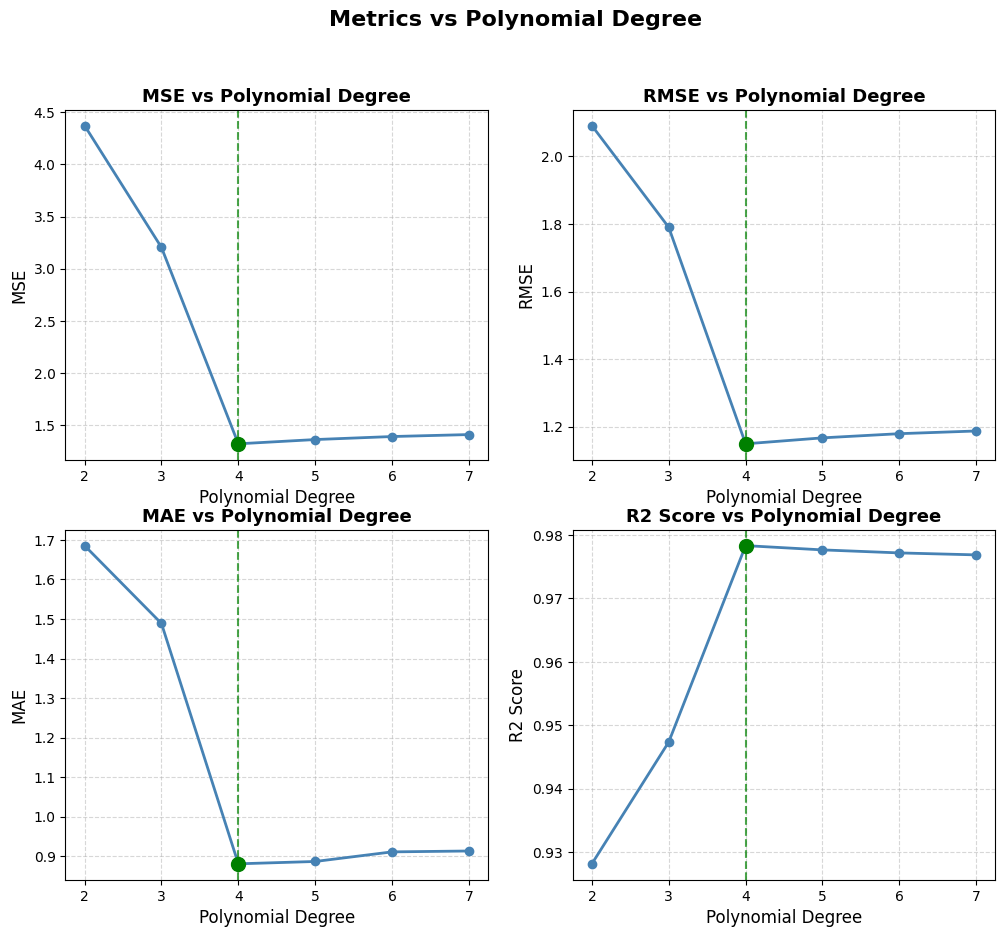

In [12]:
poly_results = results[results["Model"] != "Linear Regression"].copy() 
poly_results["Degree"] = degrees

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Metrics vs Polynomial Degree", fontsize=16, fontweight='bold')

metrics = ["MSE", "RMSE", "MAE", "R2 Score"]
for ax, metric in zip(axes.flatten(), metrics):
    ax.plot(poly_results["Degree"], poly_results[metric], marker='o', linewidth=2, color='steelblue')
    
    # Identify best degree
    if metric == "R2 Score":
        best_row = poly_results.loc[poly_results[metric].idxmax()]
    else:
        best_row = poly_results.loc[poly_results[metric].idxmin()]
        
    best_color = "green"
    d_best = best_row["Degree"]
    val_best = best_row[metric]
    
    # Mark the best degree
    ax.axvline(d_best, color=best_color, linestyle='--', alpha=0.7, label=f"Best Degree: {int(d_best)}")
    ax.scatter([d_best], [val_best], color=best_color, s=100, zorder=5)
    
    ax.set_xlabel("Polynomial Degree", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"{metric} vs Polynomial Degree", fontsize=13, fontweight='bold')
    ax.set_xticks(degrees)
    ax.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
plt.savefig("metrics_vs_degree.png", dpi=150)
plt.show()

### 10. Interpretace: Stručně okomentujte, jaký stupeň polynomu je nejvhodnější a proč (s ohledem na metriky a tvar regresních křivek).

Nejlepší stupeň polynomu je stupeň **4**. Má nejnižší hodnoty u všech metrik chyb a nejvyšší R^2 skóre. I dle vykreslení regresní křivky je vidět, že nejlépe indikuje trend.

# Cvičení: Vytvořte nelineární regresní model
### 1. Načtěte data misrala a BoxBOD. Vizualizujte datové sady pomocí bodového grafu.

Misrala dataset:
BoxBOD dataset:


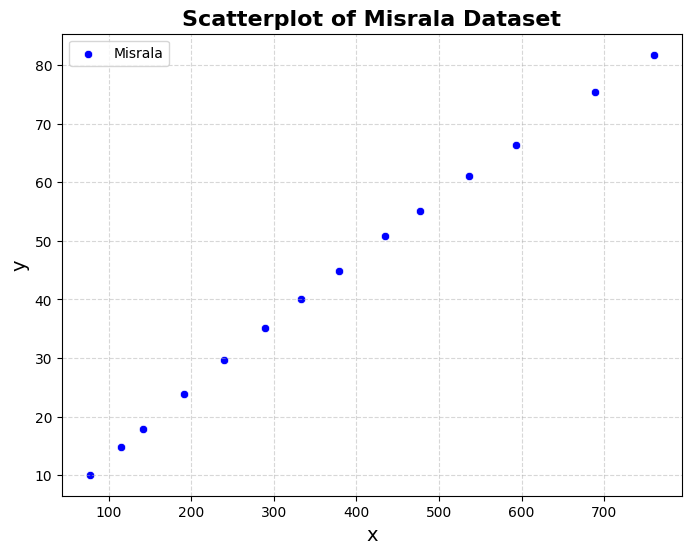

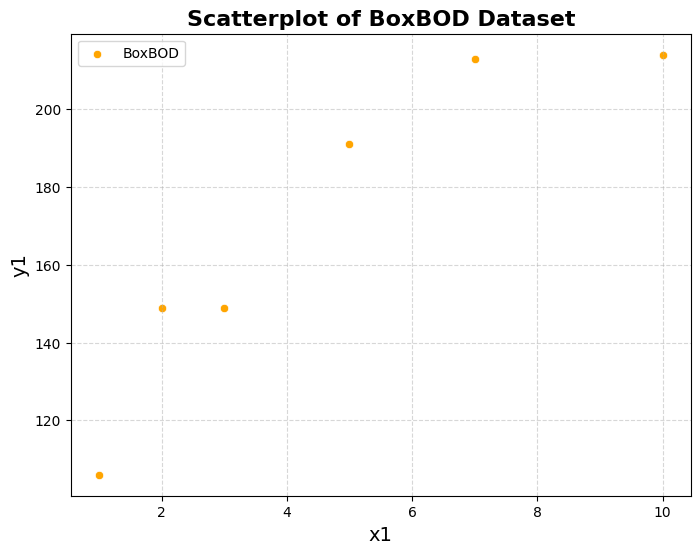

In [20]:
# Load misrala dataset
misrala = pd.read_csv("Datasets/misrala.txt", sep=r'\s+', index_col=0)
print("Misrala dataset:")
# print(misrala)
# print()

# Load BoxBOD dataset
boxbod = pd.read_csv("Datasets/BoxBOD.txt", sep=r'\s+', index_col=0)
print("BoxBOD dataset:")
# print(boxbod)

# Plot Misrala dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(data=misrala, x="x", y="y", color='blue', label='Misrala')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Scatterplot of Misrala Dataset", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("misrala_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot BoxBOD dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(data=boxbod, x="x1", y="y1", color='orange', label='BoxBOD')
plt.xlabel("x1", fontsize=14)
plt.ylabel("y1", fontsize=14)
plt.title("Scatterplot of BoxBOD Dataset", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("boxbod_scatter.png", dpi=300, bbox_inches='tight')
plt.show()